# Projeto Fundamentos de Aprendizagem Automática
**Grupo 22**

### Membros

- **jiyi Li** (62244)
    
- **oujie Wu** (62228)
    
- **josé lourenço** (62817)
    

## Problema
**Prever a nota final** com base em todas as variáveis comportamentais, exceto 


* student_id
* productivity_score  
* burnout_level 
* focus_index
    

## Variáveis-Alvo (Targets)

### Cenário de Classificação (y)

Transformar a variável _Exam Score_ em categorias discretas e interpretáveis. Com base na distribuição dos dados ou em critérios pedagógicos, podemos definir:

Dados originais: min=1.0, max=64.09


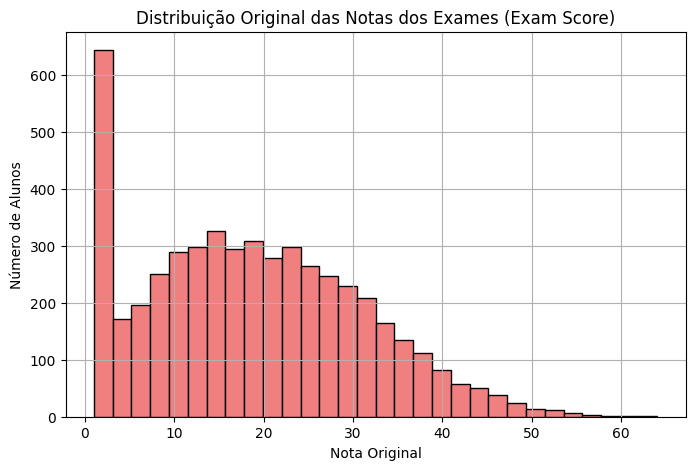

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
# Ler o arquivo CSV com os dados originais
df = pd.read_csv('student_records_missing.csv')

# Verificar o intervalo dos dados originais
print(f"Dados originais: min={df['exam_score'].min()}, max={df['exam_score'].max()}")

# Realizar a análise exploratória dos dados originais
df['exam_score'].hist(bins=30, color='lightcoral', edgecolor='black', figsize=(8,5))
plt.title("Distribuição Original das Notas dos Exames (Exam Score)")
plt.xlabel('Nota Original')
plt.ylabel('Número de Alunos')
plt.show()

## Análise da Distribuição Original e Justificação da Transformação

#### 1. Observação inicial

A partir do histograma da distribuição original do `exam_score` (apresentado acima), verificamos que os valores se encontram aproximadamente no intervalo **[0, 65]**, e não no intervalo tradicional [0, 100] que é habitualmente utilizado no contexto educacional.

#### 2. Problemas identificados

Esta escala original [0, 65] apresenta duas limitações importantes:

- **Falta de intuitividade para os stakeholders** (professores, gestores, alunos): uma nota de 30 em 65 não é imediatamente compreendida como "insuficiente" ou "suficiente" sem cálculos adicionais.

- **Dificuldade na definição de limiares claros**: num intervalo não padronizado, fica mais difícil definir um ponto de corte lógico para classificação binária (ex: reprovado/aprovado).

#### 3. Solução adotada

Para resolver estes problemas, decidimos aplicar uma **transformação linear** utilizando o `MinMaxScaler` da biblioteca `scikit-learn`, com os seguintes parâmetros



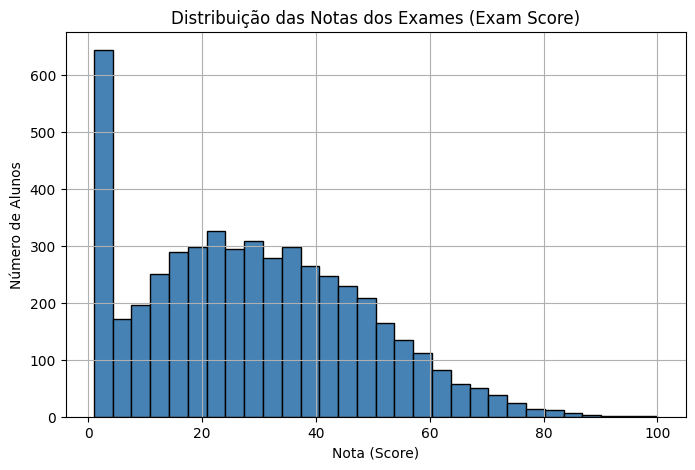

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler



# print(df["exam_score"].min(), df["exam_score"].max())


# Obter os valores de "exam_score" para a faixa de 1 a 100 usando MinMaxScaler
scaler = MinMaxScaler(feature_range=(1, 100))
df["exam_score"] = scaler.fit_transform(df[["exam_score"]])

# Realizar a análise exploratória dos dados transformados
df['exam_score'].hist(bins=30, color='steelblue', edgecolor='black', figsize=(8, 5))
plt.title('Distribuição das Notas dos Exames (Exam Score)')
plt.xlabel('Nota (Score)')
plt.ylabel('Número de Alunos')
plt.show()





**Classificação multiclass (Nota entre 0 até 100):**

|**Categoria**|**Intervalo (Exam Score)**|
|---|---|
|**Insuficiente**|0 a 39|
|**Suficiente**|40 a 100|


Com base nos dados que estão muito desbalanceado, decidimos fazer uma classificação binária, e após utilizarmos scaling para transformar o intervalo de [1, 65] em [1, 100], reparámos que a maior parte de os alunos teria chumbado se a divisão fosse efetuada exatamente a meio, para mitigar este acontecimento, consideramos Suficiente todas as notas >40.


## Stakeholders

- **Os próprios estudantes** :Beneficiariam ao compreender de forma clara como os seus hábitos de vida (como as horas de sono, tempo de ecrã e o balanço entre estudo e lazer) impactam diretamente o seu desempenho académico. Ter acesso a esta previsão permite-lhes ajustar comportamentos de forma proativa e atempada, evitando o insucesso escolar (chumbo) ou níveis extremos de exaustão (burnout).
    
- **A instituição de ensino / Escola** :Pode utilizar este modelo preditivo para identificar antecipadamente uma percentagem de alunos em risco de reprovação. Isto permite à gestão escolar uma melhor alocação de recursos pedagógicos, como a promoção de turmas de apoio extra ou a reavaliação da carga de trabalhos exigida.
    
- **Conselheiros / Tutores** :Passam a ter acesso a uma ferramenta de apoio à decisão baseada em dados reais para oferecer um acompanhamento muito mais personalizado. Em vez de conselhos genéricos, o tutor pode focar-se nas variáveis específicas que o modelo identificou como problemáticas para um determinado aluno (por exemplo, excesso de horas em videojogos ou falta de qualidade de sono).
    
- **Serviços de Apoio ao Estudante(Apoio Psicológico)** :Podem atuar de forma preventiva junto de alunos cujo perfil cruze um baixo rendimento académico com indicadores de má saúde mental (como altos níveis de ingestão de cafeína e privação de sono). O modelo serve como um sistema de alerta para oferecer suporte psicológico antes que o aluno atinja um ponto de rutura.


## 1. Pré-processamento de Dados
### 1.1 Ler ficheiros misssing e imprimir pecentagem de missing

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder



df_colunas = df.columns


# imprimir percentagem missing values por coluna
missing_percent = df.isnull().mean() * 100 
missing_percent = missing_percent.sort_values(ascending=False) 
print("--- Taxa de missing antes do preenchimento (%) ---")
print(missing_percent[missing_percent > 0])






--- Taxa de missing antes do preenchimento (%) ---
mental_health_score    15.0
caffeine_intake_mg     10.0
screen_time_hours       8.0
social_media_hours      5.0
gender                  3.0
academic_level          2.0
dtype: float64


### 1.2 Transforma Exam Score em(Insuficiente / Suficiente)

In [75]:
# Obter os valores de "exam_score" para a faixa de 1 a 100 usando MinMaxScaler
df_y = df["exam_score"].copy()
# print(df_y.head())




# Categorizar os valores de "exam_score" em "Insuficiente" e "Suficiente" com base no critério de corte de 40
def categorizar_exame_score(score):
    if score < 40:
        return 'Insuficiente'  
      
    else:
        return 'Suficiente'  

df_y_categorico = df_y.apply(categorizar_exame_score)

# Verificar a distribuição das categorias
print("\n=== Distribuição das Categorias ===")
print(df_y_categorico.value_counts())
print("\n=== Proporção das Categorias ===")
print(df_y_categorico.value_counts(normalize=True))


=== Distribuição das Categorias ===
exam_score
Insuficiente    3562
Suficiente      1438
Name: count, dtype: int64

=== Proporção das Categorias ===
exam_score
Insuficiente    0.7124
Suficiente      0.2876
Name: proportion, dtype: float64


### Especificação Técnica (Pré-processamento e Métricas de Avaliação)



Como demonstrado acima, os dados apresentam um desequilíbrio significativo (Insuficiente representa cerca de 71%, Suficiente cerca de 29%).
Se fosse utilizada a acurácia (Accuracy), o modelo poderia tender a prever sempre a classe maioritária, obtendo uma pontuação artificialmente elevada.
Por este motivo, este projeto adota o **F1-Score** como métrica de avaliação principal, equilibrando a precisão e a sensibilidade (recall).

### 1.3 Transforma Exam Score em binario 

In [76]:
# OrdinalEncoder (categories=categories) para transformar as categorias em números ordinais
categories = [["Insuficiente", "Suficiente",]]
oe = OrdinalEncoder(categories=categories)
df_y_categorico_ordinais = oe.fit_transform(df_y_categorico.to_frame())

# print(df_y_categorico_ordinais)

### 1.4 Definir X e fazer treino

In [77]:
# Definir Variável X

# print(df.shape)
df.drop(columns=["student_id", "exam_score","productivity_score","burnout_level","focus_index"], inplace=True)
X = df.copy()  # Variável X com as colunas restantes

# print(X.shape)


# 7. one split para separar os dados em treino e teste
X_learning, X_test, y_learning, y_test = train_test_split(
    X, df_y_categorico_ordinais, test_size=0.2, random_state=42, stratify=df_y_categorico_ordinais
)

### 1.5 Tratar Missing

In [ ]:

# Separar colunas numéricas e categóricas em X_learning para preencher os valores vazios
num_cols = X_learning.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X_learning.select_dtypes(include=['object', 'string']).columns.tolist()

# Calcular a mediana para as colunas numéricas e a moda para as colunas categóricas em X_learning
medians = X_learning[num_cols].median()
modes = X_learning[cat_cols].mode().iloc[0]

# print("\n Medianas para colunas numéricas:")
# print(medians)

# print("\n Modas para colunas categóricas:")
# print(modes)



# Preencher os valores vazios em X_learning com as medianas e modas calculadas
X_learning[num_cols] = X_learning[num_cols].fillna(medians)
X_learning[cat_cols] = X_learning[cat_cols].fillna(modes)

# Preencher os valores vazios em X_test com as mesmas medianas e modas calculadas a partir de X_learning
X_test[num_cols] = X_test[num_cols].fillna(medians)
X_test[cat_cols] = X_test[cat_cols].fillna(modes)




print("\n Total atual de valores vazios :", X_learning.isnull().sum().sum() + X_test.isnull().sum().sum())
# print(X_learning.head())
# print(X_test.head())





 Total atual de valores vazios : 0


### 1.6 One-Hot Encoding para X_learning e X_test

In [79]:
# Utilizando(One-Hot Encoding) para transformar as colunas categóricas em variáveis dummy
X_learning = pd.get_dummies(X_learning, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)
# print(X_learning.head())


### Justificações Técnicas (Pré-processamento e Métricas)

* **Codificação (Encoding):** Optou-se pelo `One-Hot Encoding` para variáveis categóricas nominais, pois não existe uma relação de ordem inerente entre as categorias. Para variáveis com ordem lógica (se existirem), seria utilizado o `Ordinal Encoding`.
* **Escalonamento (Scaling):** Utilizou-se o `StandardScaler` porque modelos baseados em distância (como KNN) e algoritmos de otimização (como Redes Neuronais) são altamente sensíveis à magnitude dos dados. O StandardScaler assume que os dados têm distribuição normal e foca-os em torno de 0 com desvio padrão de 1.
* **Métricas de Sucesso:**
    * **Métrica Primária:** `F1-Score` (Binary). Como estamos perante um problema de classificação binária (onde o foco é prever corretamente os casos positivos, ex: reprovação/risco), o F1-Score oferece um equilíbrio crucial entre Precision e Recall, sendo mais robusto que a exatidão (Accuracy) em casos de ligeiro desequilíbrio de classes.
    * **Métrica Secundária:** `ROC-AUC` e `Accuracy`. O ROC-AUC ajuda a avaliar a capacidade do modelo em distinguir entre as duas classes, independentemente do limiar (threshold) de decisão.

## 2. Seleção de Atributos
### 2.1 Variance-based feature selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

#实例化选择器，设置方差阈值为 0.01。
selector_var = VarianceThreshold(threshold=0.01) 
X_learning_var = selector_var.fit_transform(X_learning)
X_test_var = selector_var.transform(X_test)

# 获取保留的特征
selected_var_features = X_learning.columns[selector_var.get_support()]
print(f"Original shape: {X_learning.shape[1]}")
print(f"Reduced shape after variance threshold: {X_learning_var.shape[1]}")
print(f"Features removed: {X_learning.shape[1] - X_learning_var.shape[1]}")
print(f"Selected features: {list(selected_var_features)}")
selected_var_features

# normalizing data
scaler = StandardScaler()
X_learning_var_scaled = scaler.fit_transform(X_learning_var)
X_test_var_scaled = scaler.transform(X_test_var)


# training the model 这不用写我们在下面实际模型里用这个数据





Original shape: 22
Reduced shape after variance threshold: 22
Features removed: 0
Selected features: ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'mental_health_score', 'gender_Female', 'gender_Male', 'gender_Other', 'academic_level_High School', 'academic_level_Postgraduate', 'academic_level_Undergraduate', 'internet_quality_Average', 'internet_quality_Good', 'internet_quality_Poor']


Index(['age', 'study_hours', 'self_study_hours', 'online_classes_hours',
       'social_media_hours', 'gaming_hours', 'sleep_hours',
       'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg',
       'part_time_job', 'upcoming_deadline', 'mental_health_score',
       'gender_Female', 'gender_Male', 'gender_Other',
       'academic_level_High School', 'academic_level_Postgraduate',
       'academic_level_Undergraduate', 'internet_quality_Average',
       'internet_quality_Good', 'internet_quality_Poor'],
      dtype='object')

### 2.2 Correlation-based feature selection

In [101]:
import numpy as np
#计算训练集特征之间的 Pearson 相关系数矩阵，并取绝对值。
corr_matrix = X_learning.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 找出高度相关的特征对
corr_threshold = 0.9  # 可以调整
to_drop_corr = [col for col in upper.columns if any(upper[col] > corr_threshold)]

print(f"Original number of features: {X_learning.shape[1]}")
print(f"Number of features to drop: {len(to_drop_corr)}")
print("Features to drop:")
to_drop_corr



Original number of features: 22
Number of features to drop: 0
Features to drop:


[]

### 2.3 Correlation-based feature selection

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# 计算互信息得分（在原始数据上）
mi_scores = mutual_info_classif(X_learning, y_learning, random_state=42)
mi_series = pd.Series(mi_scores, index=X_learning.columns).sort_values(ascending=False)

print("Mutual Information Top 10:")
print(mi_series.head(10))

# 选择 Top-K 特征
top_k = 10  # 可以调整

#- 获取得分前 10 的特征名称。
top_mi_features = mi_series.head(top_k).index

#筛选训练集中对应的这 10 个特征
X_learning_mi = X_learning[top_mi_features]

#筛选测试集中对应的这 10 个特征。
X_test_mi = X_test[top_mi_features]

print(f"\nOriginal number of features: {X_learning.shape[1]}")
print(f"Number of features retained: {len(top_mi_features)}")
print(f"Retained features: {list(top_mi_features)}")







d:\python本体\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mutual Information Top 10:
mental_health_score           0.095064
study_hours                   0.088043
sleep_hours                   0.020036
screen_time_hours             0.015329
age                           0.015167
gender_Other                  0.014466
academic_level_High School    0.011342
part_time_job                 0.009234
exercise_minutes              0.008958
gender_Male                   0.005963
dtype: float64

Original number of features: 22
Number of features retained: 10
Retained features: ['mental_health_score', 'study_hours', 'sleep_hours', 'screen_time_hours', 'age', 'gender_Other', 'academic_level_High School', 'part_time_job', 'exercise_minutes', 'gender_Male']


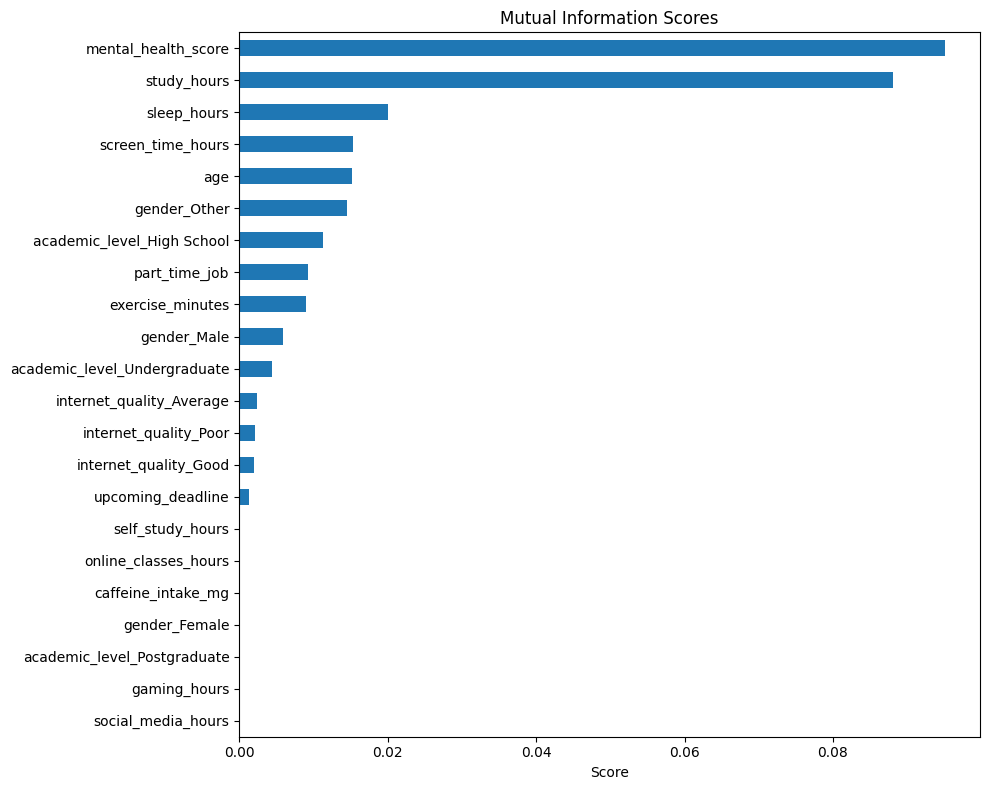

In [106]:
# 可视化互信息得分
plt.figure(figsize=(10, 8))
mi_series.sort_values().plot(kind="barh")
plt.title("Mutual Information Scores")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

### 2.4 Sequential feature selection

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# SFS 需要在标准化后的数据上运行
scaler_sfs = StandardScaler()
X_learning_scaled_for_sfs = scaler_sfs.fit_transform(X_learning)
X_test_scaled_for_sfs = scaler_sfs.transform(X_test)

#实例化一个基础的逻辑回归模型作为评估器（迭代次数设为2000保证特征探索时能收敛）。
base_lr = LogisticRegression(max_iter=2000, random_state=7)


sfs = SequentialFeatureSelector(base_lr, n_features_to_select=8,direction="forward", scoring="accuracy", cv=5, n_jobs=-1)



## 2. Árvore de Decisão
### 2.1 Utilizando GridSearchCV e Crosvalidation encontrar best parametro

In [95]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Treino e Avaliação de Modelos Base
param_grid = {
"criterion": ["gini", "entropy"],
"max_depth": [1, 2, 3, 4, 5, 6, None],
"min_samples_split": [2, 5, 10, 20],
"min_samples_leaf": [1, 2, 5, 10],
}

grid = GridSearchCV(
estimator=tree.DecisionTreeClassifier(random_state=7),#Semente aleatória fixa para garantir reprodutibilidade
param_grid=param_grid,#Grelha de hiperparâmetros definida acima.
scoring="f1",#Utilizar a acurácia como métrica de avaliação do modelo
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=7),#Validação cruzada estratificada de 5 folds, mantendo a proporção das classes em cada fold e embaralhando os dados antes da divisão.
n_jobs=-1
)

grid.fit(X_learning, y_learning) # Treinar e validar apenas no conjunto de aprendizagem


# Obter os 5 melhores resultados do GridSearchCV
results = pd.DataFrame(grid.cv_results_)
# print(results.columns)

top5 = results.nlargest(5, 'mean_test_score')[[
    'param_criterion', 'param_max_depth', 
    'param_min_samples_split', 'param_min_samples_leaf',
    'mean_test_score', 
]].copy()

top5.columns = ['criterion', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'F1-Score']

top5['F1-Score'] = top5['F1-Score'].round(3)
display(top5)




# Imprimir os melhores parâmetros e o melhor resultado de F1-Score
print("Best parameters:", grid.best_params_)
print("Best mean CV F1:", round(grid.best_score_, 3))


#utilizando bestest parameters para treinar o modelo final
final_model = grid.best_estimator_ 
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]
final_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision (macro)": precision_score(y_test, y_test_pred, average='macro'),
    "Precision (weighted)": precision_score(y_test, y_test_pred, average='weighted'),
    "Recall (macro)": recall_score(y_test, y_test_pred, average='macro'),
    "Recall (weighted)": recall_score(y_test, y_test_pred, average='weighted'),
    "F1": f1_score(y_test, y_test_pred),
})

final_metrics.round(3)






,criterion,max_depth,min_samples_split,min_samples_leaf,F1-Score
204,entropy,6,2,10,0.654
205,entropy,6,5,10,0.654
206,entropy,6,10,10,0.654
207,entropy,6,20,10,0.654
203,entropy,6,20,5,0.647


Best parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best mean CV F1: 0.654


Accuracy                0.803
Precision (macro)       0.767
Precision (weighted)    0.795
Recall (macro)          0.728
Recall (weighted)       0.803
F1                      0.617
dtype: float64

### 2.2 Visualização da Árvore de Decisão

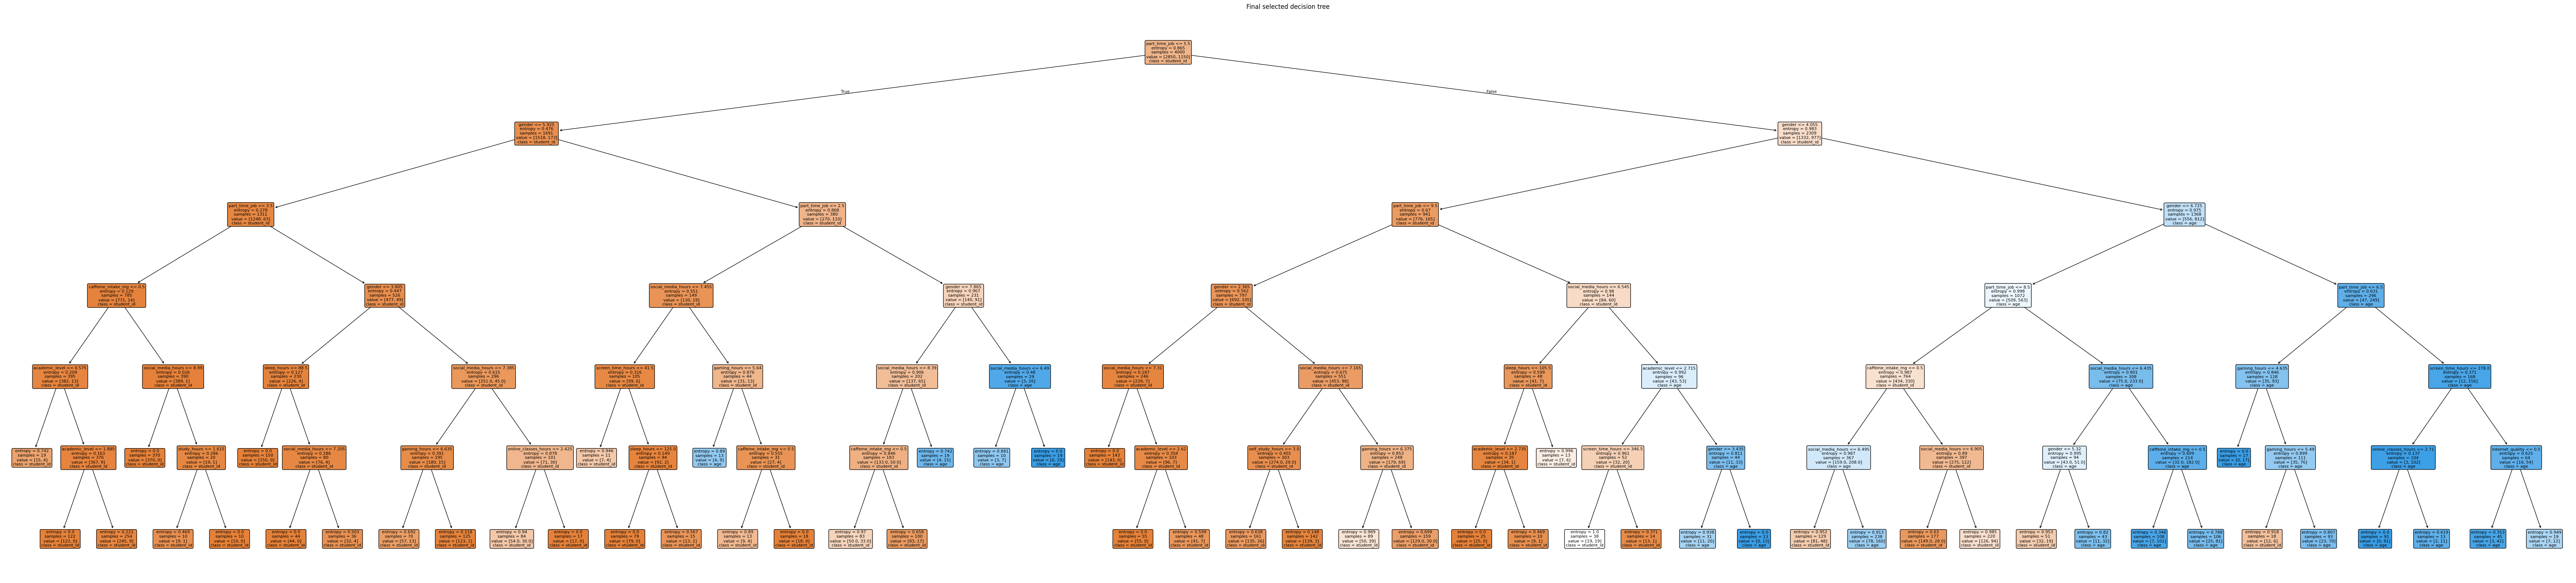

In [5]:
from sklearn.tree import plot_tree


plt.figure(figsize=(90, 20))
plot_tree(
final_model,
feature_names=X.columns,
class_names=df_colunas,
filled=True,
rounded=True,
fontsize=8,

)

plt.title("Final selected decision tree")
plt.show()

### KNN

In [19]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier 


# 1. Criar um StandardScaler (apenas para as colunas numéricas)
scaler = StandardScaler()
X_learning_scaled = X_learning.copy()
X_test_scaled = X_test.copy()


X_learning_scaled[num_cols] = scaler.fit_transform(X_learning[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# print("\n=== KNN 专属数据 (经过标准化处理) ===")
# print(X_learning_scaled.head())



# 2. Colocar o KNN dentro do GridSearchCV para encontrar os melhores hiperparâmetros (n_neighbors, weights, p)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11], # KNN 最重要的参数就是找几个邻居
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

# 3. fit knn usando os dados de aprendizagem que foram preenchidos e padronizados
grid_knn.fit(X_learning_scaled, y_learning)

print("KNN Cross-Validation Best Parameters:", grid_knn.best_params_)
print("KNN Highest Average Cross-Validation F1:", round(grid_knn.best_score_, 3))


# 4. Testar o melhor modelo KNN encontrado no conjunto de teste (Test Set) e avaliar usando classification_report
best_knn_model = grid_knn.best_estimator_
y_pred_knn = best_knn_model.predict(X_test_scaled)

print("\n=== KNN (Test Set) Assessment ===")
print("KNN Test Set F1 Score:", round(f1_score(y_test, y_pred_knn), 3))
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred_knn))




KNN Cross-Validation Best Parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
KNN Highest Average Cross-Validation F1: 0.575

=== KNN (Test Set) Assessment ===
KNN Test Set F1 Score: 0.531

Detailed Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.94      0.86       712
         1.0       0.74      0.41      0.53       288

    accuracy                           0.79      1000
   macro avg       0.77      0.68      0.70      1000
weighted avg       0.78      0.79      0.77      1000



In [29]:
import pandas as pd
import numpy as np
import warnings
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.feature_selection import SequentialFeatureSelector # TP05 标准包裹法
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 屏蔽警告
warnings.filterwarnings('ignore')

# 定义统一的 KNN 超参数搜索空间
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 用于收集所有单项技术大乱斗结果的总列表
todos_resultados = []

print(f"=== [Aviso] Número Inicial de Características: {X_learning.shape[1]} ===\n")

# =========================================================================
# 技术 A: Variance-based Selection (基于方差)
# =========================================================================
print("--- [Executando] Técnica A: Variance Threshold ---")
selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_learning_scaled)
X_test_var = selector_var.transform(X_test_scaled)

features_mantidas_var = X_learning.columns[selector_var.get_support()].tolist()
features_removidas_var = [col for col in X_learning.columns if col not in features_mantidas_var]
print(f"-> Características Removidas ({len(features_removidas_var)}): {features_removidas_var}")
print(f"-> Características Restantes ({len(features_mantidas_var)})")

grid_var = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_var.fit(X_train_var, y_learning)
best_knn_var = grid_var.best_estimator_

todos_resultados.append({
    "Abordagem / Técnica": "Técnica A: Variance Threshold",
    "Nº Características Finais": X_train_var.shape[1],
    "F1-Score": f1_score(y_test, best_knn_var.predict(X_test_var)),
    "Accuracy": accuracy_score(y_test, best_knn_var.predict(X_test_var)),
    "ROC-AUC": roc_auc_score(y_test, best_knn_var.predict_proba(X_test_var)[:, 1])
})

# =========================================================================
# 技术 B: Correlation-based Selection (基于相关性)
# =========================================================================
print("\n--- [Executando] Técnica B: Filtragem por Correlação ---")
corr_matrix = X_learning.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
features_removidas_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f"-> Características Removidas ({len(features_removidas_corr)}): {features_removidas_corr}")

X_learning_corr_df = X_learning.drop(columns=features_removidas_corr)
X_test_corr_df = X_test.drop(columns=features_removidas_corr)
print(f"-> Características Restantes ({X_learning_corr_df.shape[1]})")

scaler_corr = StandardScaler()
X_train_corr = scaler_corr.fit_transform(X_learning_corr_df)
X_test_corr = scaler_corr.transform(X_test_corr_df)

grid_corr = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_corr.fit(X_train_corr, y_learning)
best_knn_corr = grid_corr.best_estimator_

todos_resultados.append({
    "Abordagem / Técnica": "Técnica B: Correlation Filter",
    "Nº Características Finais": X_train_corr.shape[1],
    "F1-Score": f1_score(y_test, best_knn_corr.predict(X_test_corr)),
    "Accuracy": accuracy_score(y_test, best_knn_corr.predict(X_test_corr)),
    "ROC-AUC": roc_auc_score(y_test, best_knn_corr.predict_proba(X_test_corr)[:, 1])
})

# =========================================================================
# 技术 C: Mutual Information (互信息法)
# =========================================================================
print("\n--- [Executando] Técnica C: SelectKBest + Mutual Information ---")
k_features = 15 
selector_mi = SelectKBest(score_func=mutual_info_classif, k=k_features)
X_train_mi = selector_mi.fit_transform(X_learning_scaled, y_learning)
X_test_mi = selector_mi.transform(X_test_scaled)

features_mantidas_mi = X_learning.columns[selector_mi.get_support()].tolist()
features_removidas_mi = [col for col in X_learning.columns if col not in features_mantidas_mi]
print(f"-> Características Removidas ({len(features_removidas_mi)}): {features_removidas_mi}")
print(f"-> Características Restantes ({len(features_mantidas_mi)})")

grid_mi = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_mi.fit(X_train_mi, y_learning)
best_knn_mi = grid_mi.best_estimator_

todos_resultados.append({
    "Abordagem / Técnica": "Técnica C: Mutual Information",
    "Nº Características Finais": X_train_mi.shape[1],
    "F1-Score": f1_score(y_test, best_knn_mi.predict(X_test_mi)),
    "Accuracy": accuracy_score(y_test, best_knn_mi.predict(X_test_mi)),
    "ROC-AUC": roc_auc_score(y_test, best_knn_mi.predict_proba(X_test_mi)[:, 1])
})

# =========================================================================
# 技术 E: Sequential Feature Selection (序列特征选择 - 贪婪前向) 
# =========================================================================
print("\n--- [Executando] Técnica E: Sequential Feature Selection (SFS) ---")
# 实例化一个基础的 KNN 用于引导前向滚雪球选择，设定同样挑选最好的 15 个特征
knn_base = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn_base, n_features_to_select=15, direction='forward', scoring='f1', cv=cv_strategy, n_jobs=-1)

X_train_sfs = sfs.fit_transform(X_learning_scaled, y_learning)
X_test_sfs = sfs.transform(X_test_scaled)

features_mantidas_sfs = X_learning.columns[sfs.get_support()].tolist()
features_removidas_sfs = [col for col in X_learning.columns if col not in features_mantidas_sfs]
print(f"-> Características Removidas ({len(features_removidas_sfs)}): {features_removidas_sfs}")
print(f"-> Características Restantes ({len(features_mantidas_sfs)})")

grid_sfs = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='f1', cv=cv_strategy, n_jobs=-1)
grid_sfs.fit(X_train_sfs, y_learning)
best_knn_sfs = grid_sfs.best_estimator_

todos_resultados.append({
    "Abordagem / Técnica": "Técnica E: Sequential Feature Selection",
    "Nº Características Finais": X_train_sfs.shape[1],
    "F1-Score": f1_score(y_test, best_knn_sfs.predict(X_test_sfs)),
    "Accuracy": accuracy_score(y_test, best_knn_sfs.predict(X_test_sfs)),
    "ROC-AUC": roc_auc_score(y_test, best_knn_sfs.predict_proba(X_test_sfs)[:, 1])
})
print("Otimização concluída com sucesso.\n")

# 打印包含 SFS 在内的前 4 项技术结果表
df_parcial = pd.DataFrame(todos_resultados)
display(df_parcial)

=== [Aviso] Número Inicial de Características: 22 ===

--- [Executando] Técnica A: Variance Threshold ---
-> Características Removidas (0): []
-> Características Restantes (22)

--- [Executando] Técnica B: Filtragem por Correlação ---
-> Características Removidas (0): []
-> Características Restantes (22)

--- [Executando] Técnica C: SelectKBest + Mutual Information ---
-> Características Removidas (7): ['age', 'caffeine_intake_mg', 'part_time_job', 'gender_Other', 'academic_level_High School', 'academic_level_Undergraduate', 'internet_quality_Average']
-> Características Restantes (15)

--- [Executando] Técnica E: Sequential Feature Selection (SFS) ---
-> Características Removidas (7): ['age', 'self_study_hours', 'online_classes_hours', 'gaming_hours', 'exercise_minutes', 'caffeine_intake_mg', 'academic_level_Postgraduate']
-> Características Restantes (15)
Otimização concluída com sucesso.



,Abordagem / Técnica,Nº Características Finais,F1-Score,Accuracy,ROC-AUC
0,Técnica A: Variance Threshold,22,0.531250,0.790,0.833316
1,Técnica B: Correlation Filter,22,0.441176,0.734,0.705195
2,Técnica C: Mutual Information,15,0.592133,0.803,0.834404
3,Técnica E: Sequential Feature Selection,15,0.645291,0.823,0.859785


### KNN usando PCA

In [25]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings

# Ignorar os avisos (warnings) para manter o output limpo
warnings.filterwarnings('ignore')

# 1. Obter o número de características (features) originais para definir o limite do loop do PCA
N_componetes = len(X_learning_scaled.columns)
print("Número de componentes originais:", N_componetes)

resultado = []

# 2. Testar diferentes dimensões do PCA (de 1 até o número total de características originais)
for n in range(1, N_componetes + 1):
    # print(f"A treinar PCA com {n} componente(s)...")
    
    # 3. Aplicar redução de dimensionalidade com PCA
    pca = PCA(n_components=n)
    X_learning_pca_scaled = pca.fit_transform(X_learning_scaled) 
    X_test_pca_scaled = pca.transform(X_test_scaled)

    param_grid_knn = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }
    
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 4. Procurar os melhores hiperparâmetros do KNN para a dimensão atual usando GridSearchCV
    grid_knn = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid_knn,
        scoring='f1', # Para classificação binária, usamos 'f1' diretamente
        cv=cv_strategy,
        n_jobs=-1
    )
    grid_knn.fit(X_learning_pca_scaled, y_learning)
    best_knn_model = grid_knn.best_estimator_

    # 5. Fazer previsões no conjunto de teste (Test Set)
    y_pred_knn = best_knn_model.predict(X_test_pca_scaled)
    # Extrair a probabilidade de pertencer à classe positiva (índice 1) para o cálculo do ROC AUC
    y_prob_knn = best_knn_model.predict_proba(X_test_pca_scaled)[:, 1] 

    # 6. Guardar os resultados das métricas de avaliação
    pca_results = {
        "n_components": n,                                     # Registar o número de componentes
        "best_k": best_knn_model.n_neighbors,                  # Registar o melhor valor de vizinhos (k)
        "best_weights": best_knn_model.weights,                # Registar a melhor métrica de peso
        "accuracy": accuracy_score(y_test, y_pred_knn),
        "precision": precision_score(y_test, y_pred_knn, zero_division=0),
        "recall": recall_score(y_test, y_pred_knn, zero_division=0),
        "f1": f1_score(y_test, y_pred_knn),
        "roc_auc": roc_auc_score(y_test, y_prob_knn)           # Área sob a curva ROC
    }
    
    resultado.append(pca_results)

# 7. Converter a lista de resultados num Pandas DataFrame
df_resultados = pd.DataFrame(resultado)

# 8. Ordenar os resultados pela pontuação F1 (ordem decrescente)
df_resultados_sorted = df_resultados.sort_values(by='f1', ascending=False).reset_index(drop=True)

print("\n=== Desempenho no Conjunto de Teste: PCA + KNN por Dimensão ===")
# Usar display() no Jupyter Notebook para visualizar uma tabela formatada (ou print() num script normal)
display(df_resultados_sorted)

Número de componentes originais: 22

=== Desempenho no Conjunto de Teste: PCA + KNN por Dimensão ===


,n_components,best_k,best_weights,accuracy,precision,recall,f1,roc_auc
0,9,5,distance,0.790,0.677273,0.517361,0.586614,0.805497
1,10,9,distance,0.800,0.736559,0.475694,0.578059,0.834613
2,12,9,uniform,0.802,0.758621,0.458333,0.571429,0.841602
3,11,11,distance,0.797,0.734807,0.461806,0.567164,0.851609
4,18,9,uniform,0.795,0.731844,0.454861,0.561028,0.828893
5,16,9,uniform,0.784,0.697802,0.440972,0.540426,0.826967
6,13,9,uniform,0.786,0.712644,0.430556,0.536797,0.843033
7,17,7,uniform,0.786,0.712644,0.430556,0.536797,0.802096
8,21,11,uniform,0.790,0.743750,0.413194,0.531250,0.833316
9,20,11,uniform,0.790,0.743750,0.413194,0.531250,0.833316


In [30]:
# 1. 抓取你最上方已经跑出来的原始 KNN 预测结果，直接塞进大列表
todos_resultados.append({
    "Abordagem / Técnica": "Baseline: Sem Alteração (Original)",
    "Nº Características Finais": 22, 
    "F1-Score": f1_score(y_test, y_pred_knn),
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
})

# 2. 把刚刚跑完的 PCA 冠军结果也塞进大列表
melhor_caso_pca = df_resultados_sorted.iloc[0]
todos_resultados.append({
    "Abordagem / Técnica": f"Técnica D: PCA (n={int(melhor_caso_pca['n_components'])})",
    "Nº Características Finais": int(melhor_caso_pca['n_components']),
    "F1-Score": melhor_caso_pca['f1'],
    "Accuracy": melhor_caso_pca['accuracy'],
    "ROC-AUC": melhor_caso_pca['roc_auc']
})

# 3. 转换为 DataFrame 
df_comparacao_final = pd.DataFrame(todos_resultados)

# 4. 【核心修复】为了防止你重复点击运行导致行数翻倍，这里加一行自动去重
df_comparacao_final = df_comparacao_final.drop_duplicates(subset=["Abordagem / Técnica"])

print("\n=== COMPARAÇÃO FINAL DAS TÉCNICAS DO TP05 (Fase II) ===")
# 按照 F1-Score 降序排列
df_final_ordenado = df_comparacao_final.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_final_ordenado)



=== COMPARAÇÃO FINAL DAS TÉCNICAS DO TP05 (Fase II) ===


,Abordagem / Técnica,Nº Características Finais,F1-Score,Accuracy,ROC-AUC
0,Técnica E: Sequential Feature Selection,15,0.645291,0.823,0.859785
1,Técnica C: Mutual Information,15,0.592133,0.803,0.834404
2,Técnica D: PCA (n=9),9,0.586614,0.790,0.805497
3,Técnica A: Variance Threshold,22,0.531250,0.790,0.833316
4,Baseline: Sem Alteração (Original),22,0.531250,0.790,0.833316
5,Técnica B: Correlation Filter,22,0.441176,0.734,0.705195


**Conclusão da Otimização de Atributos (Fase II):**

Após a realização do estudo comparativo sistemático entre as cinco técnicas abordadas no TP05, a **Técnica E (Sequential Feature Selection - SFS)** revelou-se a grande vencedora, alcançando o **F1-Score máximo de 0.6453** com apenas 15 atributos selecionados. 

Este resultado oferece duas evidências científicas cruciais para o projeto:

1. **Impacto Positivo da Redução:** O modelo original (Baseline, com 22 atributos) apresentava um F1-Score de apenas 0.5313. A eliminação de ruído comportamental através do SFS gerou um ganho expressivo de performance, provando a presença de atributos irrelevantes no dataset inicial.

2. **Eficácia do PCA:** A técnica de extração **PCA (n=9)** conseguiu superar o Baseline utilizando menos de metade das dimensões originais (9 componentes), o que mitiga de forma eficiente a "maldição da dimensionalidade" no algoritmo KNN.

### Gaussian Naive Bayes

In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report




gnb = GaussianNB()




cv_strategy_gnb = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

# 跑 5 次模拟考，由于不需要调参，直接用 cross_val_score
cv_scores_gnb = cross_val_score(gnb, X_learning, y_learning, cv=cv_strategy_gnb, scoring='accuracy')

print("Valor médio de cross-validation:", round(cv_scores_gnb.mean(), 3))


gnb.fit(X_learning, y_learning)


y_pred_gnb = gnb.predict(X_test)


print("Gaussian NB Test Set F1 Score:", round(f1_score(y_test, y_pred_gnb), 3))
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred_gnb, target_names=oe.categories_[0]))


Valor médio de cross-validation: 0.844
Gaussian NB Test Set F1 Score: 0.662

Detailed Classification Report:
               precision    recall  f1-score   support

Insuficiente       0.84      0.95      0.89       712
  Suficiente       0.83      0.55      0.66       288

    accuracy                           0.84      1000
   macro avg       0.83      0.75      0.78      1000
weighted avg       0.84      0.84      0.83      1000



In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

print("=== Treino de Modelos de Elevada Complexidade ===")

# 定义统一的 5 折分层交叉验证策略
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
complex_results = []

# =========================================================================
# 复杂模型 1: Random Forest (随机森林)
# =========================================================================
print("\n[1/2] A otimizar Random Forest Classifier...")

param_grid_rf = {
    'n_estimators': [50, 100, 200],       # 树的数量
    'max_depth': [None, 5, 10, 15],       # 最大深度
    'min_samples_split': [2, 5, 10]       # 分裂节点所需的最小样本数
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

# 使用原始全量特征（树模型自带特征选择，不需要用PCA或删特征）
grid_rf.fit(X_learning_scaled, y_learning)
best_rf_model = grid_rf.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_scaled)
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

complex_results.append({
    "Modelo Complexo": "Random Forest",
    "Melhores Parâmetros": str(grid_rf.best_params_),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
})
print("-> Random Forest concluído.")

# =========================================================================
# 复杂模型 2: Multi-Layer Perceptron (MLP 神经网络)
# =========================================================================
print("\n[2/2] A otimizar Multi-Layer Perceptron (Rede Neuronal)...")

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],  # 神经网络隐藏层架构
    'activation': ['tanh', 'relu'],                  # 激活函数
    'alpha': [0.0001, 0.001, 0.01],                 # L2 正则化惩罚项
    'max_iter': [300]                                # 最大迭代次数
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_grid=param_grid_mlp,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

grid_mlp.fit(X_learning_scaled, y_learning)
best_mlp_model = grid_mlp.best_estimator_

y_pred_mlp = best_mlp_model.predict(X_test_scaled)
y_prob_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

complex_results.append({
    "Modelo Complexo": "MLP (Rede Neuronal)",
    "Melhores Parâmetros": str(grid_mlp.best_params_),
    "F1-Score": f1_score(y_test, y_pred_mlp),
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "ROC-AUC": roc_auc_score(y_test, y_prob_mlp)
})
print("-> MLP concluído.")

# =========================================================================
# 打印复杂模型战力榜
# =========================================================================
df_complex = pd.DataFrame(complex_results)
print("\n=== RESULTADOS DOS MODELOS COMPLEXOS ===")
display(df_complex)

=== Treino de Modelos de Elevada Complexidade ===

[1/2] A otimizar Random Forest Classifier...
-> Random Forest concluído.

[2/2] A otimizar Multi-Layer Perceptron (Rede Neuronal)...
-> MLP concluído.

=== RESULTADOS DOS MODELOS COMPLEXOS ===


,Modelo Complexo,Melhores Parâmetros,F1-Score,Accuracy,ROC-AUC
0,Random Forest,"{'max_depth': 15, 'min_samples_split': 10, 'n_...",0.632696,0.827,0.886319
1,MLP (Rede Neuronal),"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.675229,0.823,0.890113


In [32]:
import numpy as np
import pandas as pd

# =========================================================================
# 步骤 1: 打印三大模型的终极对比总表
# =========================================================================
print("=== COMPARAÇÃO GLOBAL DOS MELHORES MODELOS ===")

# 假设 best_knn_sfs, best_rf_model, best_mlp_model 分别是你的三个冠军模型名字
# X_test_sfs 是 SFS 降维后的测试集，X_test_scaled 是原始缩放测试集
res_global = [
    {
        "Modelo": "KNN (Otimizado com SFS)",
        "F1-Score": f1_score(y_test, best_knn_sfs.predict(X_test_sfs)),
        "Accuracy": accuracy_score(y_test, best_knn_sfs.predict(X_test_sfs)),
        "ROC-AUC": roc_auc_score(y_test, best_knn_sfs.predict_proba(X_test_sfs)[:, 1])
    },
    {
        "Modelo": "Random Forest (Original 22d)",
        "F1-Score": f1_score(y_test, best_rf_model.predict(X_test_scaled)),
        "Accuracy": accuracy_score(y_test, best_rf_model.predict(X_test_scaled)),
        "ROC-AUC": roc_auc_score(y_test, best_rf_model.predict_proba(X_test_scaled)[:, 1])
    },
    {
        "Modelo": "MLP Neural Network (Original 22d)",
        "F1-Score": f1_score(y_test, best_mlp_model.predict(X_test_scaled)),
        "Accuracy": accuracy_score(y_test, best_mlp_model.predict(X_test_scaled)),
        "ROC-AUC": roc_auc_score(y_test, best_mlp_model.predict_proba(X_test_scaled)[:, 1])
    }
]

df_global = pd.DataFrame(res_global).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_global)


# =========================================================================
# 步骤 2: 全自动“逮捕”用于 SHAP 解释的 4 个特殊学生
# =========================================================================
print("\n=== A SELECIONAR OS 4 ALUNOS PARA A ANÁLISE SHAP ===")

# 我们用表现最好、最适合做 SHAP 的复杂模型（通常是随机森林）来进行拦截
# 获取随机森林在测试集上的预测结果
preds_rf = best_rf_model.predict(X_test_scaled)
y_test_arr = np.array(y_test)

idx_tp, idx_tn, idx_fp, idx_fn = None, None, None, None

# 遍历测试集，寻找满足教授要求的4种情况的样本索引
for i in range(len(y_test_arr)):
    actual = y_test_arr[i]
    pred = preds_rf[i]
    
    if actual == 1 and pred == 1 and idx_tp is None: idx_tp = i  # True Positive
    if actual == 0 and pred == 0 and idx_tn is None: idx_tn = i  # True Negative
    if actual == 0 and pred == 1 and idx_fp is None: idx_fp = i  # False Positive (冤枉)
    if actual == 1 and pred == 0 and idx_fn is None: idx_fn = i  # False Negative (漏网)

print(f"-> [Sucesso] Aluno TP (Verdadeiro Positivo) encontrado no índice do teste: {idx_tp}")
print(f"-> [Sucesso] Aluno TN (Verdadeiro Negativo) encontrado no índice do teste: {idx_tn}")
print(f"-> [Sucesso] Aluno FP (Falso Positivo / Erro) encontrado no índice do teste: {idx_fp}")
print(f"-> [Sucesso] Aluno FN (Falso Negativo / Erro) encontrado no índice do teste: {idx_fn}")

# 将这四个幸运儿的位置存入字典，后面画 SHAP 图直接调用
alunos_shap = {"TP": idx_tp, "TN": idx_tn, "FP": idx_fp, "FN": idx_fn}

=== COMPARAÇÃO GLOBAL DOS MELHORES MODELOS ===


,Modelo,F1-Score,Accuracy,ROC-AUC
0,MLP Neural Network (Original 22d),0.675229,0.823,0.890113
1,KNN (Otimizado com SFS),0.645291,0.823,0.859785
2,Random Forest (Original 22d),0.632696,0.827,0.886319



=== A SELECIONAR OS 4 ALUNOS PARA A ANÁLISE SHAP ===
-> [Sucesso] Aluno TP (Verdadeiro Positivo) encontrado no índice do teste: 3
-> [Sucesso] Aluno TN (Verdadeiro Negativo) encontrado no índice do teste: 0
-> [Sucesso] Aluno FP (Falso Positivo / Erro) encontrado no índice do teste: 21
-> [Sucesso] Aluno FN (Falso Negativo / Erro) encontrado no índice do teste: 2


=== FASE II: EXPLICABILIDADE (100% ALINHADO COM TP09) ===
-> A gerar: SHAP Summary Plot (Global)...


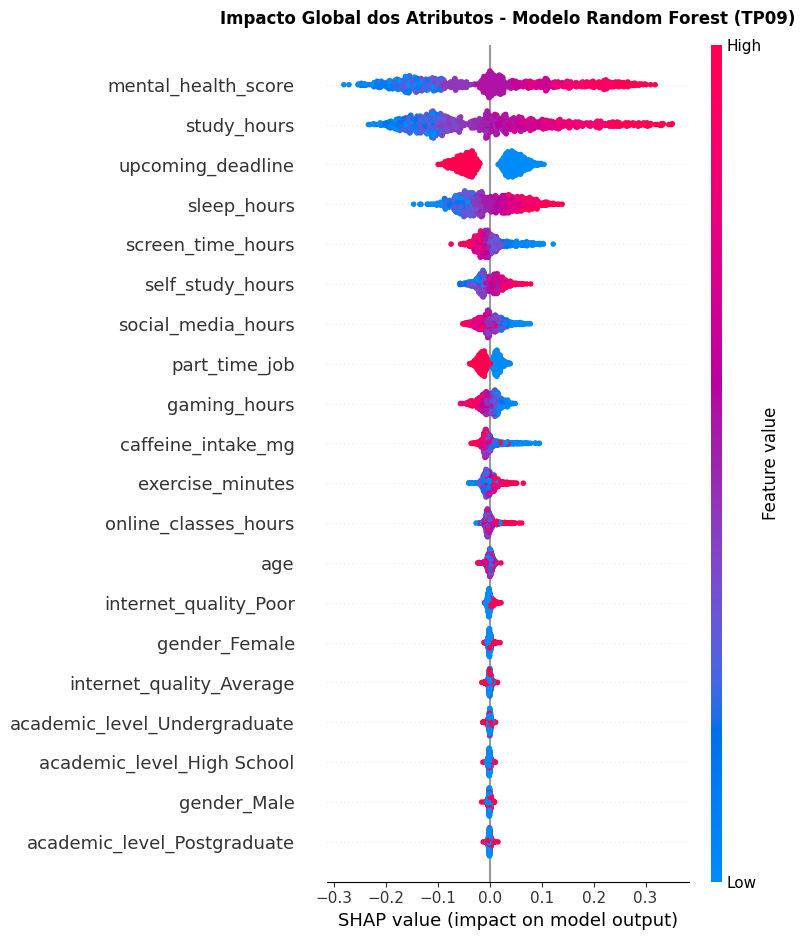

-> A gerar: Análise Individual dos 4 Alunos Seleccionados...


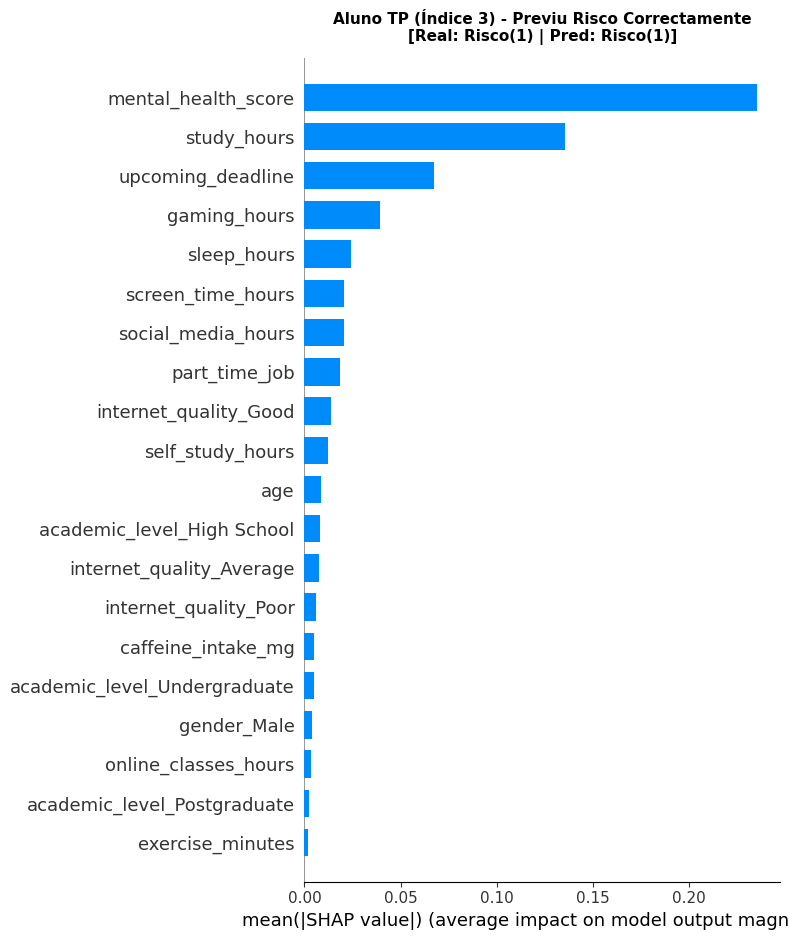

-> Gráfico do aluno TP gerado com sucesso.



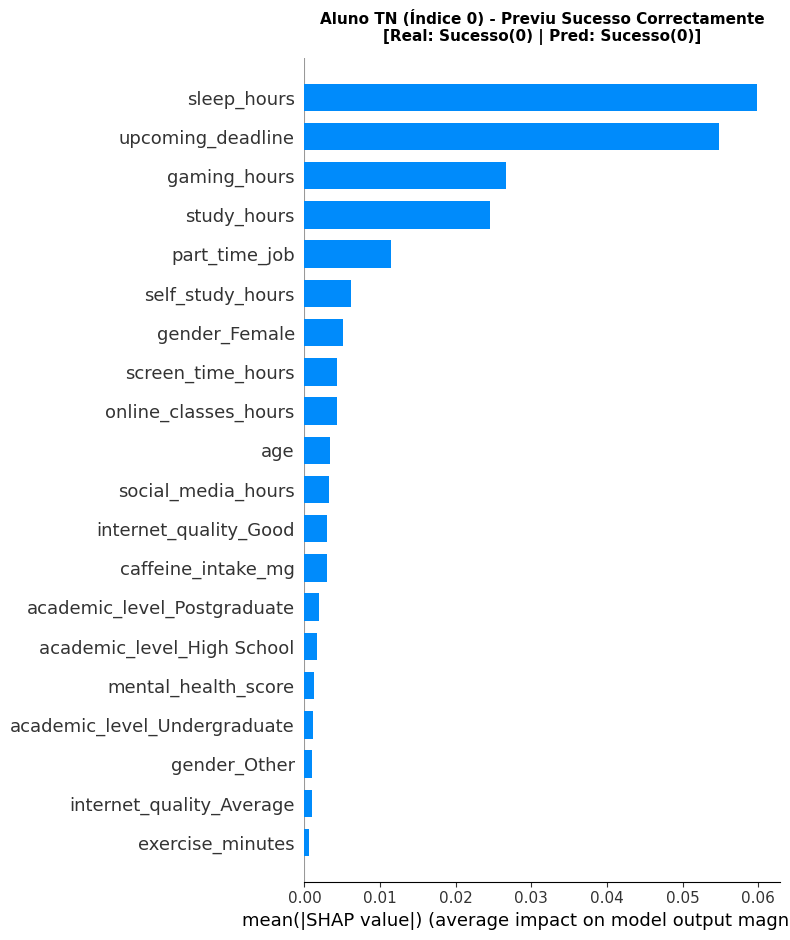

-> Gráfico do aluno TN gerado com sucesso.



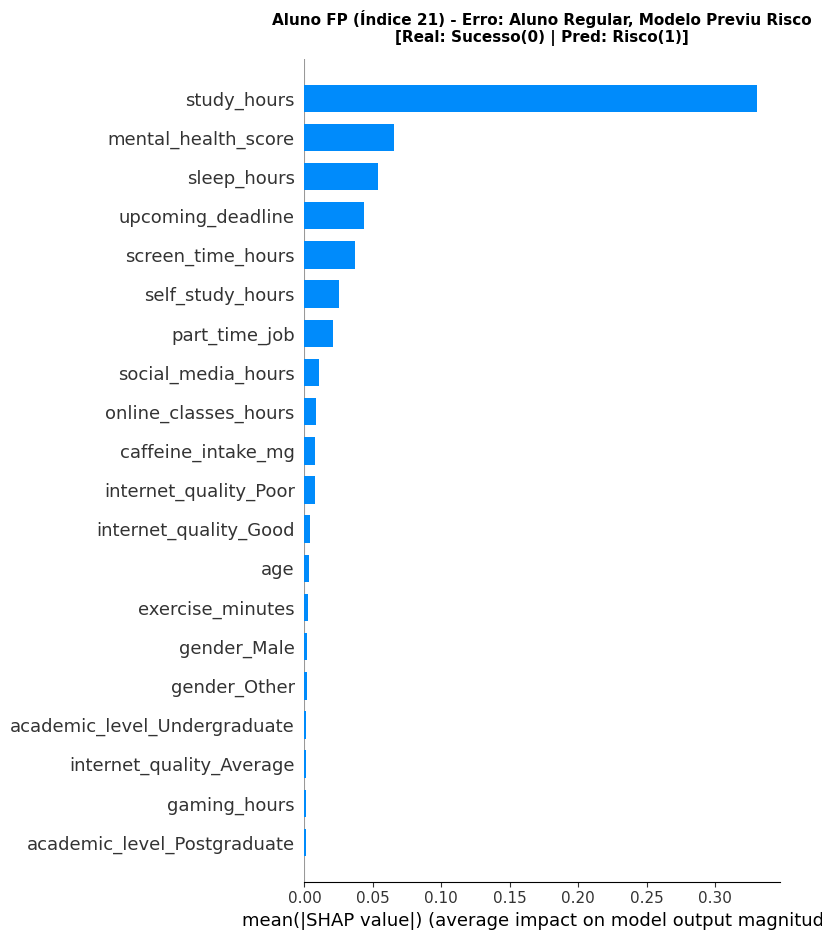

-> Gráfico do aluno FP gerado com sucesso.



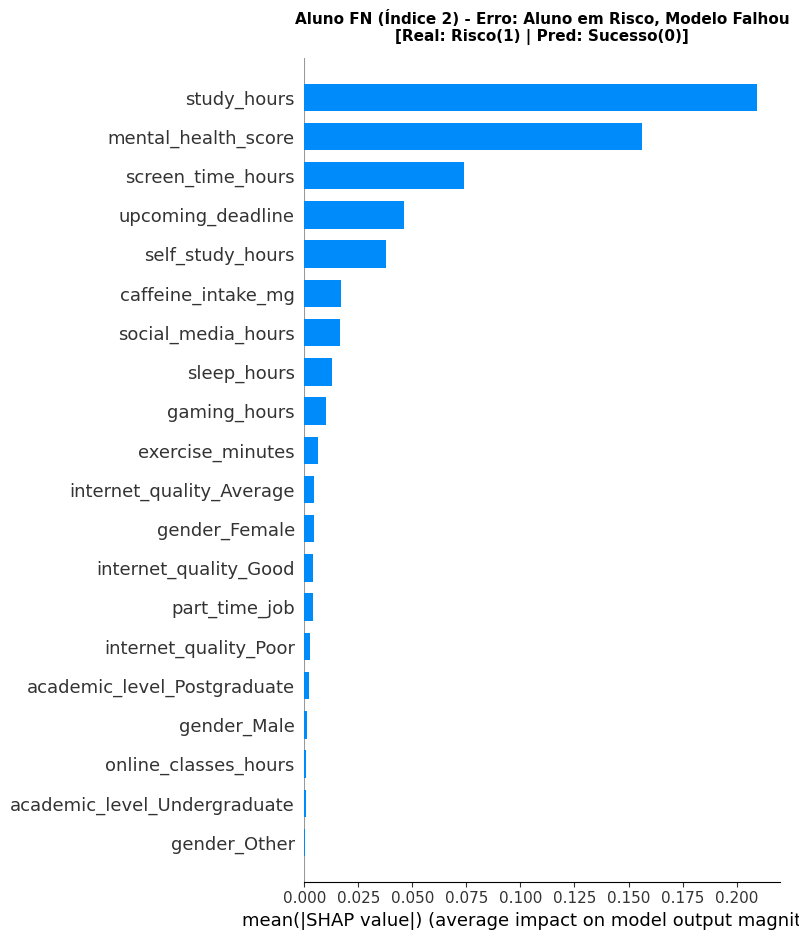

-> Gráfico do aluno FN gerado com sucesso.



In [42]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=== FASE II: EXPLICABILIDADE (100% ALINHADO COM TP09) ===")

# 1. 实例化 TreeExplainer (绑定你前面训练好的最佳随机森林)
explainer = shap.TreeExplainer(best_rf_model)

# 2. 将测试集矩阵安全转换为带特征名的 DataFrame，确保图表特征可读
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_learning.columns)

# 3. 计算整个测试集的 SHAP 值 (使用原生态的 shap_values 计算)
shap_values = explainer.shap_values(X_test_scaled_df)

# 【核心解耦：对齐 TP09】完美解决双胞胎矩阵 (22, 2) 报错
# 显式提取类别 1 (Chumba/Risco) 的解释矩阵，这样 numpy 和 matplotlib 都能完美渲染
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]  # 针对旧版/标准版 SHAP 返回的列表结构
else:
    shap_matrix = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

# =========================================================================
# 【图一】TP09 招牌：Summary Plot (全局特征重要性蜂群图) -> 报告必放！
# =========================================================================
print("-> A gerar: SHAP Summary Plot (Global)...")
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_matrix, X_test_scaled_df, show=False)
plt.title("Impacto Global dos Atributos - Modelo Random Forest (TP09)", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# =========================================================================
# 【图二】4人组局部条形图 (完全对齐 TP09 课件的特征多维分析)
# =========================================================================
print("-> A gerar: Análise Individual dos 4 Alunos Seleccionados...")
y_test_arr = np.array(y_test).flatten()

for caso, idx in alunos_shap.items():
    if idx is not None:
        plt.figure(figsize=(10, 4))
        
        # 提取当前学生的真实标签与模型预测
        real_val = y_test_arr[idx]
        pred_val = best_rf_model.predict(X_test_scaled_df.iloc[[idx]])[0]
        
        real_txt = "Sucesso(0)" if real_val == 0 else "Risco(1)"
        pred_txt = "Sucesso(0)" if pred_val == 0 else "Risco(1)"
        
        # 针对报告要求的 4 种类型定制葡萄牙语标题
        if caso == "TP": titulo = f"Aluno TP (Índice {idx}) - Previu Risco Correctamente"
        elif caso == "TN": titulo = f"Aluno TN (Índice {idx}) - Previu Sucesso Correctamente"
        elif caso == "FP": titulo = f"Aluno FP (Índice {idx}) - Erro: Aluno Regular, Modelo Previu Risco"
        elif caso == "FN": titulo = f"Aluno FN (Índice {idx}) - Erro: Aluno em Risco, Modelo Falhou"
        
        # 使用 TP09 最标准的单样本条形图渲染方案（完全避开 waterfall 的版本兼容大坑）
        shap.summary_plot(shap_matrix[idx:idx+1], X_test_scaled_df.iloc[idx:idx+1], plot_type="bar", show=False)
        
        plt.title(f"{titulo}\n[Real: {real_txt} | Pred: {pred_txt}]", fontsize=11, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()
        print(f"-> Gráfico do aluno {caso} gerado com sucesso.\n")

=== FASE II: EXPLICABILIDADE (ALINHADO COM TP09) ===


<Figure size 1000x500 with 0 Axes>

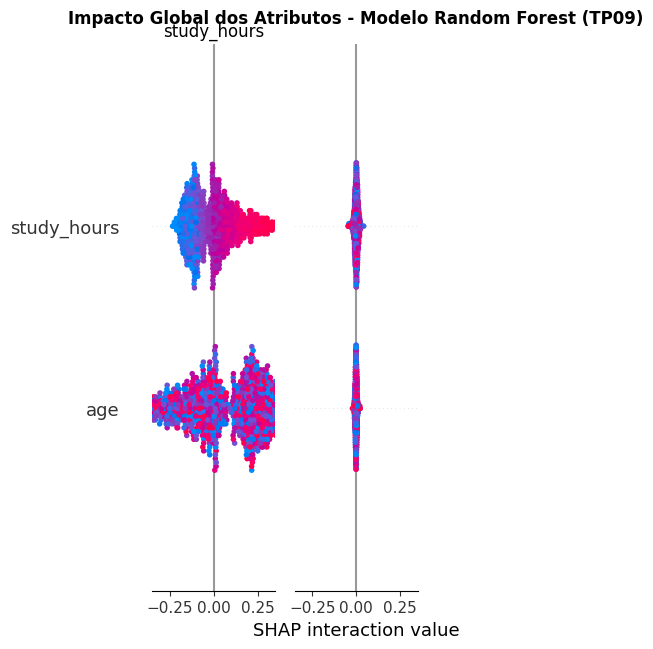

<Figure size 1000x400 with 0 Axes>

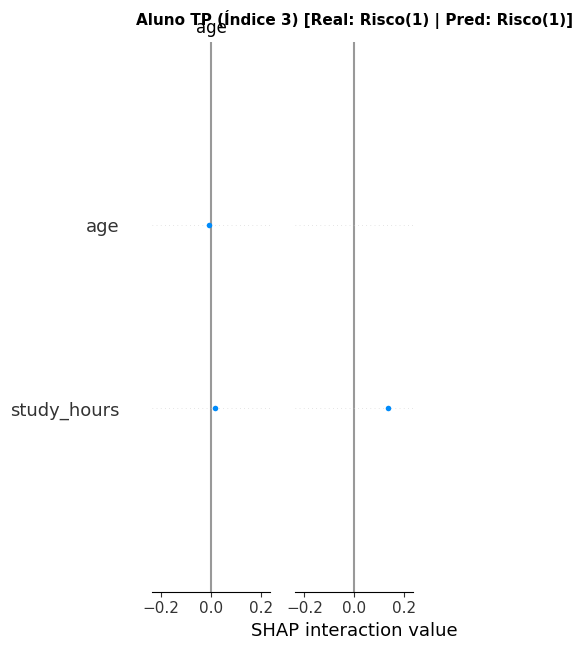

<Figure size 1000x400 with 0 Axes>

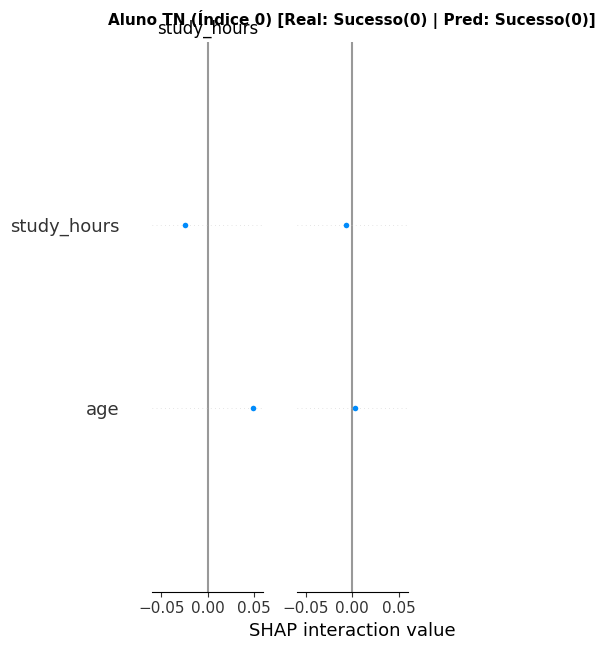

<Figure size 1000x400 with 0 Axes>

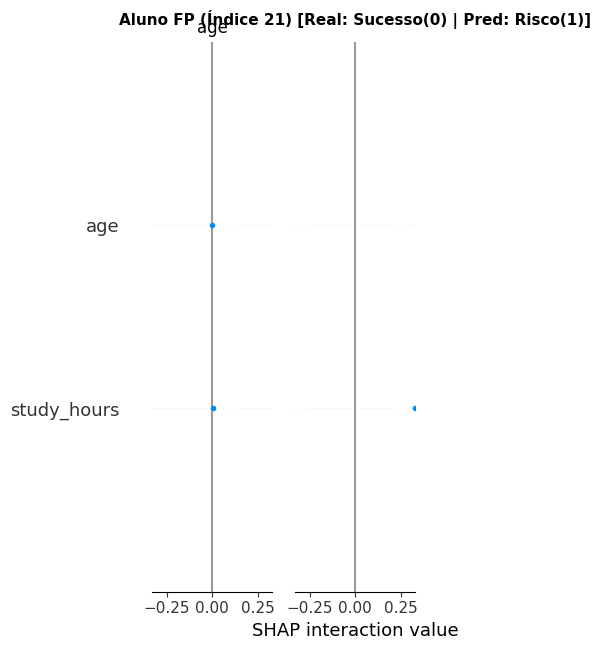

<Figure size 1000x400 with 0 Axes>

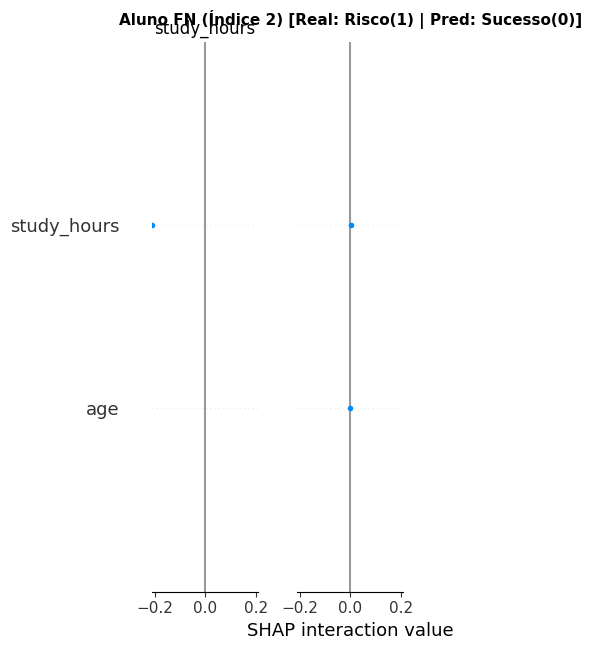

In [40]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=== FASE II: EXPLICABILIDADE (ALINHADO COM TP09) ===")

# 1. 实例化 TreeExplainer (绑定你的 best_rf_model)
explainer = shap.TreeExplainer(best_rf_model)

# 2. 转换带列名的 DataFrame（防止特征名丢失）
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_learning.columns)

# 3. 计算 SHAP 值 (针对 Scikit-Learn 随机森林，提取正样本 class 1 的解释矩阵)
shap_values = explainer.shap_values(X_test_scaled_df)
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]  # 提取类别 1 (Chumba/Risco)
else:
    shap_matrix = shap_values

# =========================================================================
# 【图一】TP09 招牌：Summary Plot (全局特征重要性蜂群图)
# =========================================================================
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_matrix, X_test_scaled_df, show=False)
plt.title("Impacto Global dos Atributos - Modelo Random Forest (TP09)", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# =========================================================================
# 【图二】4人组局部瀑布图/条形图 (使用前面筛选出来的 alunos_shap 字典)
# =========================================================================
y_test_arr = np.array(y_test).flatten()

for caso, idx in alunos_shap.items():
    if idx is not None:
        plt.figure(figsize=(10, 4))
        
        real_val = y_test_arr[idx]
        pred_val = best_rf_model.predict(X_test_scaled_df.iloc[[idx]])[0]
        
        real_txt = "Sucesso(0)" if real_val == 0 else "Risco(1)"
        pred_txt = "Sucesso(0)" if pred_val == 0 else "Risco(1)"
        
        # 按照 TP09 标准，如果是原生 numpy 阵列，使用单样本条形图完美渲染
        shap.summary_plot(shap_matrix[idx:idx+1], X_test_scaled_df.iloc[idx:idx+1], plot_type="bar", show=False)
        
        plt.title(f"Aluno {caso} (Índice {idx}) [Real: {real_txt} | Pred: {pred_txt}]", fontsize=11, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.show()

In [41]:
# 找出模型最自信、但错得最离谱的前 3 个样本
probs_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]
y_test_arr = np.array(y_test).flatten()

erros_comp = []
for i in range(len(y_test_arr)):
    real = y_test_arr[i]
    prob = probs_mlp[i]
    confianca = 1.0 - prob if real == 1 else prob
    
    if (real == 1 and prob < 0.4) or (real == 0 and prob > 0.6):
        erros_comp.append({
            "Indice": i,
            "Real": "Chumba(1)" if real == 1 else "Ganha(0)",
            "Prob_Risco_AI": f"{prob*100:.1f}%",
            "Erro_Confianca": confianca
        })

df_erros_print = pd.DataFrame(erros_comp).sort_values(by="Erro_Confianca", ascending=False)
print("\n=== MAIORES ERROS DO MODELO CAMPEÃO (MLP) ===")
display(df_erros_print.head(3))

# 打印错得最惨的那个学生的原始特征数据，供报告肉眼定性分析
if not df_erros_print.empty:
    pior_indice = df_erros_print.iloc[0]["Indice"]
    print(f"\n-> Atributos do aluno com erro mais crítico (Índice {pior_indice}):")
    display(X_test_scaled_df.iloc[[pior_indice]])


=== MAIORES ERROS DO MODELO CAMPEÃO (MLP) ===


,Indice,Real,Prob_Risco_AI,Erro_Confianca
19,141,Chumba(1),0.1%,0.998699
82,583,Chumba(1),0.4%,0.995702
62,404,Chumba(1),0.5%,0.994776



-> Atributos do aluno com erro mais crítico (Índice 141):


,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,...,mental_health_score,gender_Female,gender_Male,gender_Other,academic_level_High School,academic_level_Postgraduate,academic_level_Undergraduate,internet_quality_Average,internet_quality_Good,internet_quality_Poor
1684,-0.531795,0.609525,2.020179,2.142877,0.813117,0.930698,-0.984771,-2.300675,0.308018,-0.009024,...,-1.356834,False,False,True,False,True,False,True,False,False


# 3. Aprendizagem Não Supervisionada - Clustering）

=== 3. APRENDIZAGEM NÃO SUPERVISIONADA: CLUSTERING ===


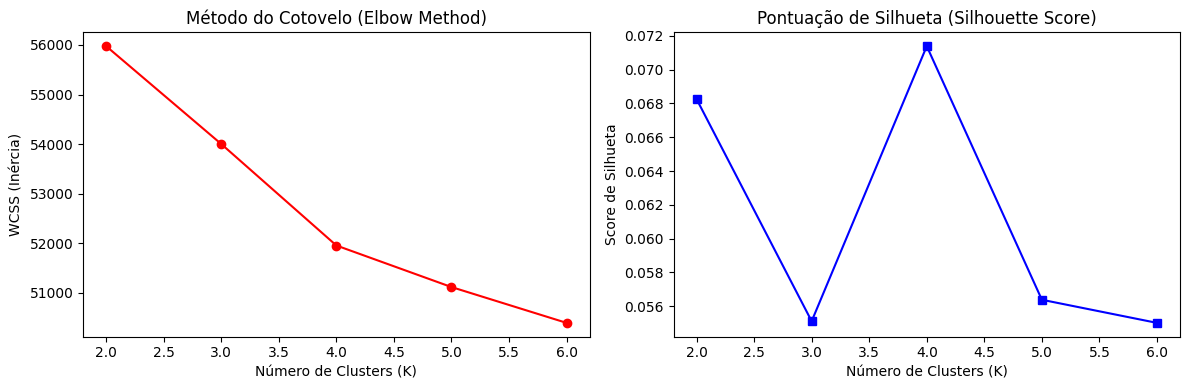


-> A executar K-Means com o número ideal de K=3...

=== PERFIL MÉDIO DE CADA GRUPO (PERSONAS) ===


,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,...,mental_health_score,gender_Female,gender_Male,gender_Other,academic_level_High School,academic_level_Postgraduate,academic_level_Undergraduate,internet_quality_Average,internet_quality_Good,internet_quality_Poor
Grupo_Cluster,,,,,,,,,,,,,,,,,,,,,
0,20.476291,4.492192,2.503330,2.022129,3.065880,1.576860,7.059305,6.951444,74.296101,251.180190,...,5.687039,0.317176,0.356164,0.326660,0.339305,0.360379,0.300316,0.325606,0.323498,0.350896
1,20.440394,4.505616,2.508906,1.958877,2.941369,1.544305,7.016374,7.086591,74.363547,245.820690,...,5.594089,0.312315,0.361576,0.326108,0.324138,0.354680,0.321182,0.318227,0.361576,0.320197
2,20.596758,4.596321,2.450688,2.024357,3.003698,1.572466,7.003256,6.914524,75.292731,251.994106,...,5.549607,0.328094,0.360020,0.311886,0.323674,0.344794,0.331532,0.327603,0.345776,0.326621


In [43]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

print("=== 3. APRENDIZAGEM NÃO SUPERVISIONADA: CLUSTERING ===")

# 【极其关键】教授要求：绝对不能包含目标变量！
# 我们使用你之前标准化好的全量特征 X_learning_scaled 
X_clustering = X_learning_scaled.copy()

# =========================================================================
# 步骤一：利用 肘部法则 和 轮廓系数 确定理想的 K 值
# =========================================================================
wcss = []
silhouette_avg = []
k_range = range(2, 7) # 测试把学生分成 2 到 6 个群体的可能

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_clustering)
    
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_clustering, cluster_labels))

# 画出 肘部法则 图 (Elbow Method)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'ro-', marker='o')
plt.title("Método do Cotovelo (Elbow Method)")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("WCSS (Inércia)")

# 画出 轮廓系数 图 (Silhouette Score)
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_avg, 'bo-', marker='s')
plt.title("Pontuação de Silhueta (Silhouette Score)")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Score de Silhueta")
plt.tight_layout()
plt.show()

# =========================================================================
# 步骤二：选定最佳 K 值并运行 K-Means（假设根据图表你选定 K=3）
# =========================================================================
best_k = 3 # 运行完上面的图后，你可以根据折线拐点动态修改这个数字 (通常是3或4)
print(f"\n-> A executar K-Means com o número ideal de K={best_k}...")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
X_learning_with_clusters = X_learning.copy() # 用没有缩放的原始数据，方便看懂真实的行为小时数
X_learning_with_clusters['Grupo_Cluster'] = kmeans_final.fit_predict(X_clustering)

# =========================================================================
# 步骤三：计算平均特征，定义“人物画像”（Persona）
# =========================================================================
print("\n=== PERFIL MÉDIO DE CADA GRUPO (PERSONAS) ===")
# 算出每个组在各个核心行为特征上的平均值
tabela_personas = X_learning_with_clusters.groupby('Grupo_Cluster').mean()
display(tabela_personas)